In [1]:
from aeon.benchmarking.published_results import (
    load_classification_bake_off_2023_results,
)
from aeon.visualisation import plot_critical_difference
import polars as pl
import numpy as np
from aeon.datasets.tsc_datasets import univariate
from tscglue import utils
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tempfile
import boto3
import polars as pl
from tqdm import tqdm
from urllib.parse import urlparse
from concurrent.futures import ThreadPoolExecutor, as_completed

In [2]:
directory = "figures"
Path(directory).mkdir(parents=True, exist_ok=True)

In [3]:
def load_s3_parquet_cached(
    s3_prefix: str = "s3://tsc-glue/performance-benchmarking/",
    max_workers: int = 16,
) -> pl.DataFrame:

    cache_dir = os.path.join(tempfile.gettempdir(), "tsc-glue-cache")
    os.makedirs(cache_dir, exist_ok=True)

    parsed = urlparse(s3_prefix)
    bucket = parsed.netloc
    prefix = parsed.path.lstrip("/")

    s3 = boto3.client("s3")

    local_files = {
        f for f in os.listdir(cache_dir) if f.endswith(".parquet")
    }

    paginator = s3.get_paginator("list_objects_v2")
    remote_keys = []

    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if key.endswith(".parquet"):
                fname = key.rsplit("/", 1)[-1]
                if fname not in local_files:
                    remote_keys.append(key)

    def _download(key):
        fname = key.rsplit("/", 1)[-1]
        s3.download_file(
            bucket,
            key,
            os.path.join(cache_dir, fname),
        )

    if remote_keys:
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = [ex.submit(_download, k) for k in remote_keys]
            for _ in tqdm(as_completed(futures), total=len(futures)):
                pass

    local_paths = sorted(
        os.path.join(cache_dir, f)
        for f in os.listdir(cache_dir)
        if f.endswith(".parquet")
    )

    return pl.read_parquet(local_paths)

res_mine = load_s3_parquet_cached()#.filter(pl.col('fold')==0)
res_mine

100%|██████████| 2877/2877 [01:10<00:00, 40.80it/s]


dataset,model,fold,test_accuracy
str,str,i64,f64
"""BirdChicken""","""loky-stacker-v7-soft-rf""",0,0.9
"""RefrigerationDevices""","""loky-stacker-v8-base-r1""",22,0.786667
"""CricketY""","""loky-stacker-v10-base-r3""",0,0.869231
"""SwedishLeaf""","""mr-hydra-contained-auto""",9,0.9776
"""BeetleFly""","""mr-hydra-kbest-5000""",15,0.95
…,…,…,…
"""OSULeaf""","""loky-stacker-v8-auto-best-base""",4,0.983471
"""CricketZ""","""loky-stacker-v8-base-r3""",6,0.882051
"""ProximalPhalanxOutlineAgeGroup""","""loky-stacker-v9-base-r2""",12,0.858537


In [4]:
res_mine = res_mine.filter(
    (pl.col("model").str.contains("loky-stacker-v5"))==False
)

In [5]:
results_arr, datasets, classifiers = load_classification_bake_off_2023_results(
    num_resamples=30, as_array=True
)
results_arr.shape

(112, 34)

In [6]:
v = res_mine.filter(pl.col('fold')==5).pivot(values="test_accuracy", index="dataset", on="model").select(['dataset', 'loky-stacker-v7', 'loky-stacker-v6'])
v.with_columns((pl.col('loky-stacker-v7') - pl.col('loky-stacker-v6')).alias('diff')).sort('diff', descending=True)

dataset,loky-stacker-v7,loky-stacker-v6,diff
str,f64,f64,f64
"""CinCECGTorso""",0.999275,0.999275,0.0
"""ECG200""",0.9,0.9,0.0
"""Crop""",0.789107,0.789107,0.0
"""SemgHandSubjectCh2""",0.942222,0.942222,0.0
"""PowerCons""",1.0,1.0,0.0
…,…,…,…
"""MoteStrain""",0.846645,0.846645,0.0
"""ElectricDevices""",0.910517,0.910517,0.0
"""CricketZ""",0.858974,0.858974,0.0


In [7]:
pivoted = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='len')
numeric_cols = [c for c in pivoted.columns if c != "dataset"]
sum_row = pl.DataFrame([{"dataset": "all", **{c: pivoted[c].sum() for c in numeric_cols}}]).with_columns([
    pl.col(c).cast(pl.UInt32) for c in numeric_cols
])
result = pl.concat([pivoted, sum_row])
result

dataset,loky-stacker-v7-soft-rf,loky-stacker-v8-base-r1,loky-stacker-v10-base-r3,mr-hydra-contained-auto,mr-hydra-kbest-5000,mycatch22v2,mycatch22,loky-stacker-v6-soft-ridge,loky-stacker-v6,mr-hydra-kbest-auto,loky-stacker-v6-soft-et,loky-stacker-v8-auto-best-base,mymrhydrav2,loky-stacker-v8-base,loky-stacker-v10-base,mydummy,loky-stacker-v8-base-r3,loky-stacker-v7,loky-stacker-v8-auto-best-stacking,chronos2,mr-hydra-kbest-10000,loky-stacker-v10-base-2x,loky-stacker-v6-soft-rf,loky-stacker-v7-soft-filter-ridge,loky-stacker-v7-soft-et,mr-hydra-kbest-30000,loky-stacker-v7-soft-ridge,loky-stacker-v9-base-r2,loky-stacker-v8-auto-best,TSCGlue-3-3-26,loky-stacker-v10-base-5x,mymrhydra,loky-stacker-v9-base-r1,loky-stacker-v9-base-r3
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""BirdChicken""",30,30,8,30,30,30,30,30,30,30,30,30,30,30,30,30,18,30,30,23,30,30,30,30,30,30,30,20,30,30,17,30,30,2
"""RefrigerationDevices""",30,30,6,30,30,30,30,30,30,30,30,30,30,30,30,30,22,30,30,22,30,30,30,30,30,30,30,19,30,30,17,30,30,2
"""CricketY""",30,30,4,30,30,30,30,30,30,30,30,30,30,30,30,30,17,30,30,24,30,30,30,30,30,30,30,14,30,30,12,30,30,4
"""SwedishLeaf""",30,30,8,30,30,30,30,30,30,30,30,30,30,30,30,30,20,30,30,26,30,30,30,30,30,30,30,20,30,30,19,30,30,2
"""BeetleFly""",30,30,11,30,30,30,30,30,30,30,30,30,30,30,30,30,21,30,30,19,30,30,30,30,30,30,30,22,30,30,19,30,30,4
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""EOGHorizontalSignal""",30,30,8,30,30,30,30,30,30,30,30,30,30,30,30,30,22,30,30,21,30,30,30,30,30,30,30,18,30,30,21,30,30,5
"""Coffee""",30,30,9,30,30,30,30,30,30,30,30,30,30,30,30,30,20,30,30,20,30,30,30,30,30,30,30,20,30,30,20,30,30,4
"""DistalPhalanxOutlineCorrect""",30,30,7,30,30,30,30,30,30,30,30,30,30,30,30,30,21,30,30,22,30,29,30,30,30,30,30,22,30,30,11,30,30,2


In [8]:
mine_classifiers = res_mine['model'].unique().to_list()

In [9]:
df_performance = pl.DataFrame(results_arr, schema=classifiers).with_columns(pl.Series("dataset", datasets))
df_performance_mine = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='mean')
df_performance_full = df_performance.join(other=df_performance_mine, on='dataset')

In [10]:
df_performance_full = df_performance_full#.drop(mine_classifiers)
len(df_performance_full)

112

In [11]:
df_performance_full = df_performance_full.drop([col for col in df_performance_full.columns if df_performance_full[col].null_count() > 0])

In [12]:
drop_models = ['ShapeDTW', 'EE', 'ResNet', 'CNN', 
               'CIF', 'BOSS', 'TSFresh', 'Arsenal', 
               'HC1', 'Hydra', '1NN-DTW', 'ROCKET', 
               'Mini-R', 'WEASEL-D', 'InceptionT', 'Signatures', 'RISE', 'DrCIF', 'TDE', 
               #'loky-stacker-v5-soft-et',
               #'loky-stacker-v5-soft-ridge',	
               #'loky-stacker-v5-soft-rf',	
               #'loky-stacker-v5-r1',
               'loky-stacker-v6',
               'loky-stacker-v6-soft-ridge',
               'loky-stacker-v6-soft-et',
               'loky-stacker-v6-soft-rf',
               'mymrhydra', 'mymrhydrav2',
               'mr-hydra-kbest-5000',
               'mr-hydra-kbest-10000',
               'mr-hydra-kbest-30000',
                'mycatch22v2', 'mycatch22',
                'mr-hydra-contained-auto',
                'mr-hydra-kbest-auto',
                'loky-stacker-v7',
                'loky-stacker-v7-soft-ridge',
                'loky-stacker-v7-soft-rf',
                'loky-stacker-v7-soft-et',
                'mydummy',
                'loky-stacker-v8-auto-best',
                'loky-stacker-v8-auto-best-base',
                'loky-stacker-v8-auto-best',
]

In [13]:
df_performance_full = df_performance_full.drop(drop_models)

In [14]:
df_performance_full.columns

['Catch22',
 'FreshPRINCE',
 'HC2',
 'Hydra-MR',
 'MrSQM',
 'Multi-R',
 'PF',
 'RDST',
 'RSF',
 'RSTSF',
 'STC',
 'TS-CHIEF',
 'TSF',
 'WEASEL',
 'cBOSS',
 'dataset',
 'loky-stacker-v8-base-r1',
 'loky-stacker-v10-base-r3',
 'loky-stacker-v8-base',
 'loky-stacker-v10-base',
 'loky-stacker-v8-base-r3',
 'loky-stacker-v8-auto-best-stacking',
 'chronos2',
 'loky-stacker-v10-base-2x',
 'loky-stacker-v7-soft-filter-ridge',
 'TSCGlue-3-3-26',
 'loky-stacker-v10-base-5x',
 'loky-stacker-v9-base-r1']

(<Figure size 600x460 with 1 Axes>, <Axes: >)

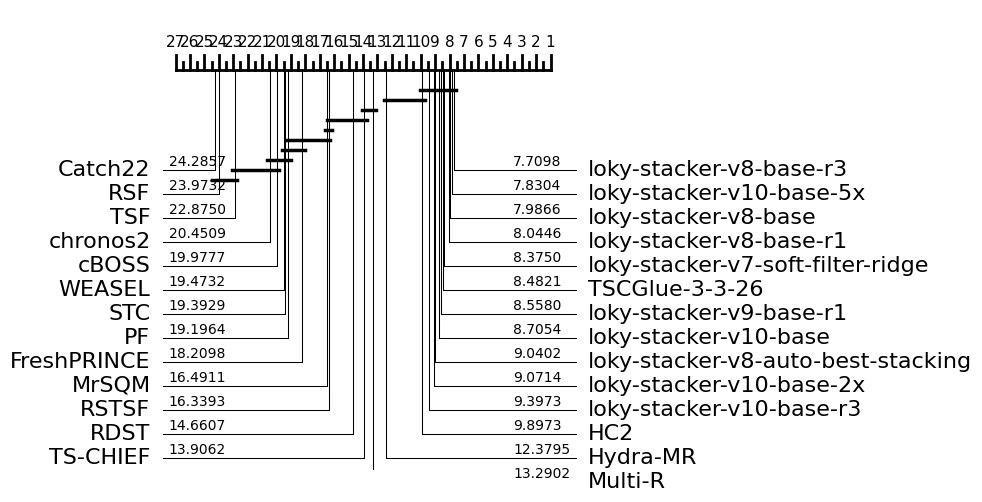

In [15]:
clsf = df_performance_full.select([c for c in df_performance_full.columns if c != "dataset"])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

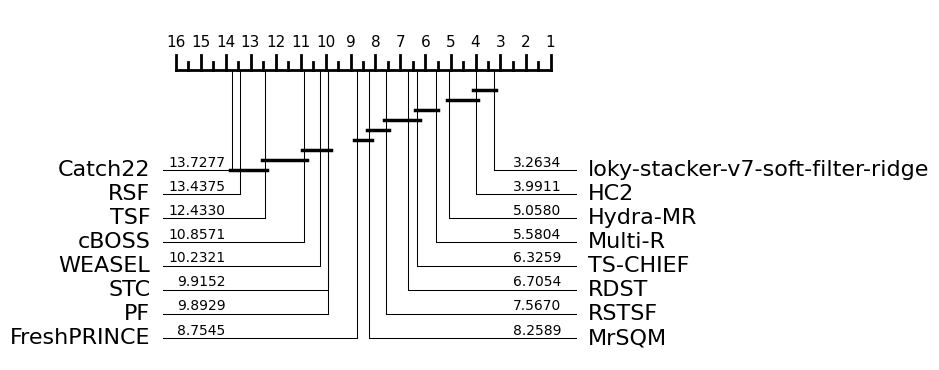

In [16]:
clsf = df_performance_full.select([
    c for c in df_performance_full.columns if c != "dataset" and (c in classifiers or c == 'loky-stacker-v7-soft-filter-ridge')
])
plot_critical_difference(clsf.to_numpy(), clsf.columns)
plt.savefig(f"{directory}/critical_difference.pdf", bbox_inches='tight', pad_inches=0)


In [17]:
clsf

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,loky-stacker-v7-soft-filter-ridge
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.888333,0.923333,0.946667,0.91,0.958333,0.89,0.903333,0.913333,0.833333,0.963333,0.915,0.963333,0.821667,0.906667,0.981667,0.941667
0.705422,0.747467,0.827022,0.748533,0.785067,0.737778,0.672356,0.750222,0.666489,0.728444,0.787378,0.726844,0.615911,0.724267,0.794756,0.783733
0.591197,0.726838,0.849915,0.844103,0.812308,0.844017,0.799829,0.847094,0.707778,0.773077,0.774359,0.817009,0.701368,0.792564,0.745726,0.858205
0.881227,0.948427,0.962613,0.97248,0.956693,0.97296,0.953067,0.963467,0.882827,0.951573,0.930507,0.96192,0.893547,0.960053,0.915573,0.975627
0.851667,0.881667,0.911667,0.911667,0.963333,0.895,0.86,0.926667,0.875,0.885,0.951667,0.958333,0.823333,0.92,0.96,0.895
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.940667,0.955556,0.999111,0.996222,0.999333,0.997778,0.991333,0.994889,0.917111,0.986222,0.989556,1.0,0.963556,0.992444,0.999556,0.996667
0.724862,0.768508,0.814917,0.871823,0.790516,0.866851,0.824401,0.779466,0.690516,0.75884,0.767127,0.853683,0.69291,0.688858,0.710313,0.881215
0.984524,0.989286,1.0,1.0,0.980952,1.0,0.991667,0.995238,0.941667,1.0,0.985714,0.990476,0.989286,0.984524,0.985714,1.0


In [18]:
#clsf = df_performance_full.select(['loky-stacker-v6-soft-ridge', 'HC2', 'Hydra-MR', 'cBOSS', 'Catch22', 'RDST', 'WEASEL'])
#plot_critical_difference(clsf.to_numpy(), clsf.columns)

(<Figure size 600x270 with 1 Axes>, <Axes: >)

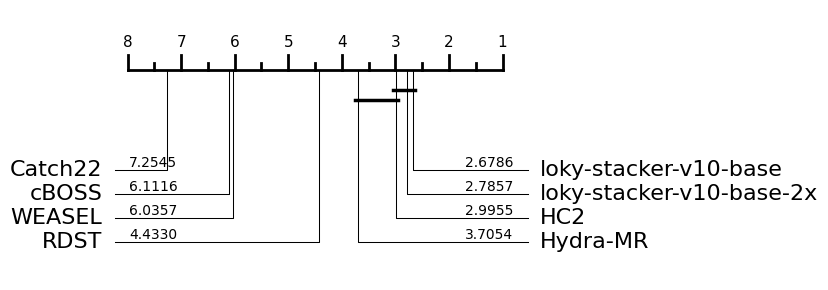

In [19]:
clsf = df_performance_full.select(['loky-stacker-v10-base', 'loky-stacker-v10-base-2x', 'HC2', 'Hydra-MR', 'cBOSS', 'Catch22', 'RDST', 'WEASEL'])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

In [20]:
df_performance_full

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,dataset,loky-stacker-v8-base-r1,loky-stacker-v10-base-r3,loky-stacker-v8-base,loky-stacker-v10-base,loky-stacker-v8-base-r3,loky-stacker-v8-auto-best-stacking,chronos2,loky-stacker-v10-base-2x,loky-stacker-v7-soft-filter-ridge,TSCGlue-3-3-26,loky-stacker-v10-base-5x,loky-stacker-v9-base-r1
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.888333,0.923333,0.946667,0.91,0.958333,0.89,0.903333,0.913333,0.833333,0.963333,0.915,0.963333,0.821667,0.906667,0.981667,"""BirdChicken""",0.941667,0.94375,0.94,0.938333,0.927778,0.94,0.95,0.938333,0.941667,0.936667,0.944118,0.936667
0.705422,0.747467,0.827022,0.748533,0.785067,0.737778,0.672356,0.750222,0.666489,0.728444,0.787378,0.726844,0.615911,0.724267,0.794756,"""RefrigerationDevices""",0.783822,0.789778,0.784089,0.783911,0.784,0.779911,0.669091,0.7856,0.783733,0.784,0.780078,0.780622
0.591197,0.726838,0.849915,0.844103,0.812308,0.844017,0.799829,0.847094,0.707778,0.773077,0.774359,0.817009,0.701368,0.792564,0.745726,"""CricketY""",0.858205,0.869872,0.858291,0.85641,0.860181,0.854103,0.717521,0.857436,0.858205,0.858974,0.85235,0.857094
0.881227,0.948427,0.962613,0.97248,0.956693,0.97296,0.953067,0.963467,0.882827,0.951573,0.930507,0.96192,0.893547,0.960053,0.915573,"""SwedishLeaf""",0.975627,0.974,0.975627,0.975947,0.97672,0.975627,0.934215,0.97568,0.975627,0.97536,0.976842,0.975893
0.851667,0.881667,0.911667,0.911667,0.963333,0.895,0.86,0.926667,0.875,0.885,0.951667,0.958333,0.823333,0.92,0.96,"""BeetleFly""",0.895,0.922727,0.895,0.901667,0.897619,0.903333,0.826316,0.896667,0.895,0.895,0.892105,0.906667
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.940667,0.955556,0.999111,0.996222,0.999333,0.997778,0.991333,0.994889,0.917111,0.986222,0.989556,1.0,0.963556,0.992444,0.999556,"""GunPoint""",0.996667,0.996667,0.996667,0.997556,0.996667,0.996889,0.988,0.997333,0.996667,0.996444,0.998413,0.997556
0.724862,0.768508,0.814917,0.871823,0.790516,0.866851,0.824401,0.779466,0.690516,0.75884,0.767127,0.853683,0.69291,0.688858,0.710313,"""EOGHorizontalSignal""",0.881123,0.887776,0.880939,0.881215,0.876946,0.877624,0.668771,0.882136,0.881215,0.881676,0.882399,0.88186
0.984524,0.989286,1.0,1.0,0.980952,1.0,0.991667,0.995238,0.941667,1.0,0.985714,0.990476,0.989286,0.984524,0.985714,"""Coffee""",1.0,1.0,1.0,0.99881,0.996429,1.0,1.0,0.997619,1.0,0.99881,0.996429,1.0


(<Figure size 600x260 with 1 Axes>, <Axes: >)

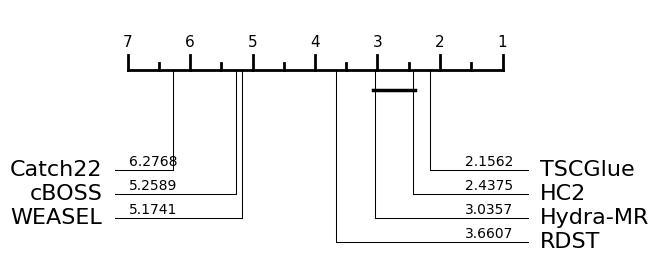

In [21]:
clsf = df_performance_full.rename({'TSCGlue-3-3-26': 'TSCGlue'}).select(['TSCGlue', 'HC2', 'Hydra-MR', 'cBOSS', 'Catch22', 'RDST', 'WEASEL'])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

In [22]:
v = (df_performance_full['loky-stacker-v10-base-2x'] - df_performance_full['HC2']).to_numpy()
(v>0).sum(), (v<0).sum(), (v==0).sum()

(np.int64(60), np.int64(48), np.int64(4))

In [23]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

df_performance_full.join(stats, on='dataset').sort('n_train')

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,dataset,loky-stacker-v8-base-r1,loky-stacker-v10-base-r3,loky-stacker-v8-base,loky-stacker-v10-base,loky-stacker-v8-base-r3,loky-stacker-v8-auto-best-stacking,chronos2,loky-stacker-v10-base-2x,loky-stacker-v7-soft-filter-ridge,TSCGlue-3-3-26,loky-stacker-v10-base-5x,loky-stacker-v9-base-r1,n_train,n_test,n_classes,series_length
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
0.908279,0.916993,0.946841,0.950436,0.890741,0.952179,0.956754,0.944989,0.919935,0.937146,0.924619,0.945861,0.940632,0.894553,0.881046,"""DiatomSizeReduction""",0.952179,0.948529,0.952179,0.952179,0.952692,0.952179,0.954902,0.952179,0.952179,0.952179,0.955786,0.952179,16,306,4,345
0.986613,0.999866,0.999331,0.984739,0.857028,0.996252,1.0,0.965194,1.0,1.0,0.905087,1.0,1.0,1.0,0.998527,"""InsectEPGSmallTrain""",1.0,1.0,1.0,1.0,1.0,1.0,0.858381,1.0,1.0,1.0,1.0,1.0,17,249,3,601
0.851667,0.881667,0.911667,0.911667,0.963333,0.895,0.86,0.926667,0.875,0.885,0.951667,0.958333,0.823333,0.92,0.96,"""BeetleFly""",0.895,0.922727,0.895,0.901667,0.897619,0.903333,0.826316,0.896667,0.895,0.895,0.892105,0.906667,20,20,2,512
0.888333,0.923333,0.946667,0.91,0.958333,0.89,0.903333,0.913333,0.833333,0.963333,0.915,0.963333,0.821667,0.906667,0.981667,"""BirdChicken""",0.941667,0.94375,0.94,0.938333,0.927778,0.94,0.95,0.938333,0.941667,0.936667,0.944118,0.936667,20,20,2,512
0.892323,0.972789,0.970068,0.965792,0.95345,0.966569,0.948019,0.968416,0.883479,0.975607,0.955102,0.961836,0.954227,0.939456,0.942857,"""Chinatown""",0.975607,0.971678,0.975607,0.973761,0.976433,0.974344,0.975948,0.974344,0.97551,0.975802,0.97272,0.974733,20,343,2,24
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.792152,0.847708,0.843706,0.859402,0.816861,0.857964,0.829099,0.829099,0.817211,0.841414,0.833877,0.82533,0.811772,0.811305,0.780109,"""PhalangesOutlinesCorrect""",0.862626,0.866966,0.862937,0.863287,0.865708,0.861772,0.818334,0.864763,0.862587,0.862937,0.867223,0.863015,1800,858,2,80
0.908636,1.0,0.953712,0.955354,0.95,0.954141,0.850025,0.949242,0.876515,0.977803,0.934242,0.947399,0.81846,0.960657,0.908939,"""FordA""",0.981439,0.981145,0.981465,0.981338,0.981402,0.984571,0.93024,0.981034,0.981414,0.981414,0.981818,0.981237,3601,1320,2,500
0.867778,0.9207,0.933868,0.931193,0.922798,0.929671,0.839383,0.928601,0.85786,0.922593,0.9193,0.919465,0.785267,0.928354,0.883086,"""FordB""",0.9407,0.948148,0.940741,0.940535,0.945385,0.939547,0.910617,0.941209,0.940741,0.940453,0.944136,0.940206,3636,810,2,500


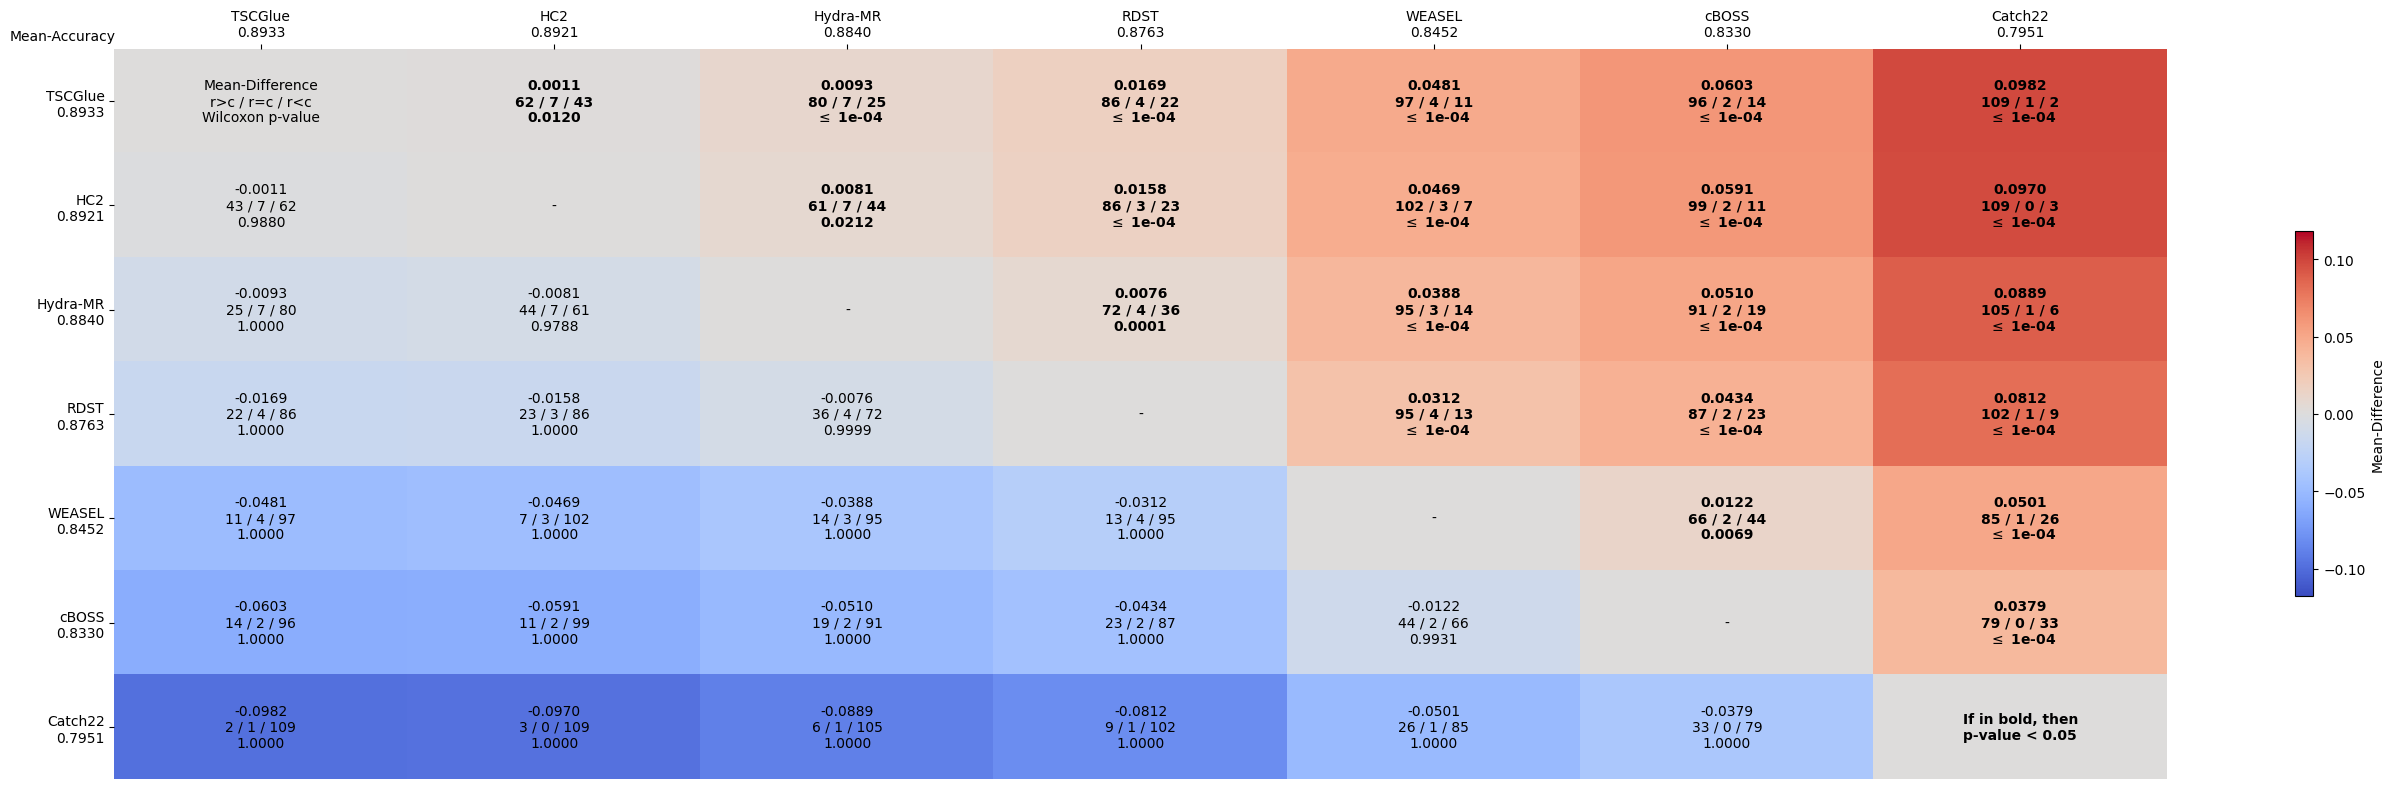

In [24]:
from aeon.visualisation import create_multi_comparison_matrix

create_multi_comparison_matrix(clsf.to_pandas())
plt.savefig(f"{directory}/multi_comparison_matrix.pdf", bbox_inches='tight', pad_inches=0)

In [25]:
def plot_acc_diff_vs_size(df, m1, m2):
    data = df.join(stats, on='dataset').with_columns(pl.col('n_train').log().alias('n_train_log')).sort('n_train')
    plt.scatter(data['n_train'], data[m1]-data[m2], s=10)
    plt.xlabel('Training Set Size')
    plt.ylabel(f'Accuracy Difference ({m1} − {m2})')
    plt.xscale('log')
    plt.grid()
    plt.axhline(0, color='black', linewidth=0.8)
    ylim = plt.gca().get_ylim()
    plt.axhspan(0, ylim[1], alpha=0.08, color='green')
    plt.axhspan(ylim[0], 0, alpha=0.08, color='red')
    plt.text(0.98, 0.95, f'{m1} better', transform=plt.gca().transAxes, ha='right', va='top', fontsize=9, color='green')
    plt.text(0.98, 0.05, f'{m2} better', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=9, color='red')
    plt.ylim(ylim)


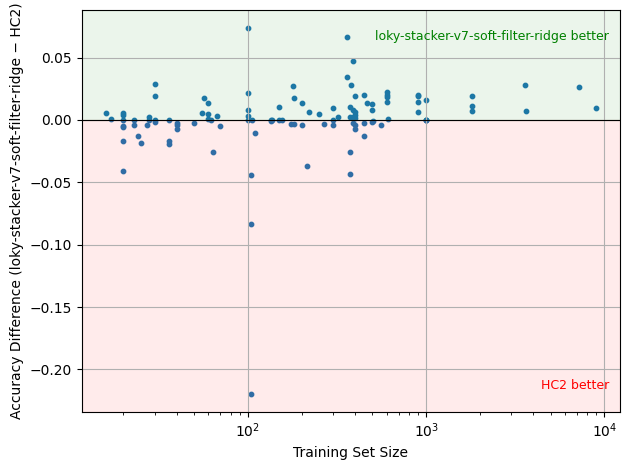

In [26]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v7-soft-filter-ridge', 'HC2')

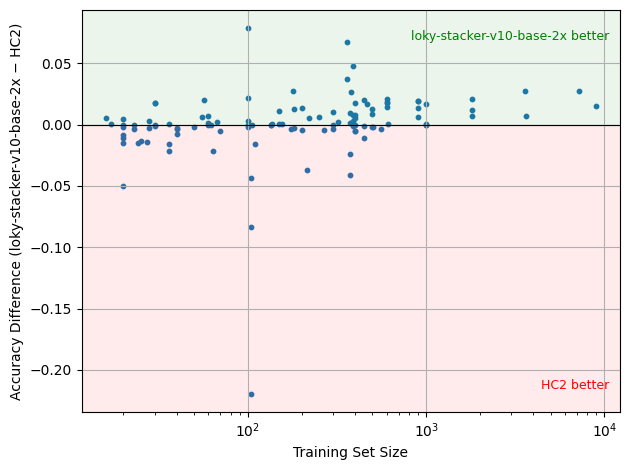

In [27]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v10-base-2x', 'HC2')


In [28]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v7-soft-ridge', 'loky-stacker-v7-soft-rf')

ColumnNotFoundError: "loky-stacker-v7-soft-ridge" not found

In [ ]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v7-soft-ridge', 'loky-stacker-v7-soft-et')

In [ ]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v7-soft-rf', 'loky-stacker-v7-soft-et')

In [ ]:
plot_acc_diff_vs_size(df_performance_full, 'loky-stacker-v8-auto-best', 'loky-stacker-v8-base')


In [ ]:
res_mine_f0 = res_mine.filter(pl.col('fold')==0)